In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-darkgrid')
print("All imports done")

All imports done


In [2]:
# Our listing gain data (target variable)
df_gains = pd.read_csv('../data/processed/ipo_clean.csv', parse_dates=['listing_date'])

# Our rich feature data (subscription + GMP)
df_features = pd.read_csv('../data/raw/investorgain_data.csv')

print(f"Gains dataset: {df_gains.shape}")
print(f"Features dataset: {df_features.shape}")

print(f"\nGains columns: {df_gains.columns.tolist()}")
print(f"\nFeatures columns: {df_features.columns.tolist()}")

print(f"\nSample company names from gains:")
print(df_gains['ipo_name'].head(5).tolist())

print(f"\nSample company names from features:")
print(df_features['company_name'].head(5).tolist())

Gains dataset: (297, 11)
Features dataset: (1380, 14)

Gains columns: ['ipo_name', 'listing_date', 'issue_price', 'listing_gain_pct', 'return_1w', 'return_4w', 'return_6w', 'listing_year', 'listing_month', 'listing_quarter', 'gain_category']

Features columns: ['year', 'company_name', 'issue_category', 'close_date', 'issue_amount_cr', 'issue_price', 'lot_size', 'pe_ratio', 'qib_x', 'nii_x', 'retail_x', 'total_x', 'gmp', 'gmp_percent']

Sample company names from gains:
['Kissht', 'Om Power', 'Powerica', 'Sai Parenteral’s', 'Aeroplane Basmati']

Sample company names from features:
['Valencia Nutrition SME', 'Prince Pipes IPO', 'DC Infotech SME', 'Ujjivan Bank IPO', 'Ascom Leasing & SME']


In [3]:
def clean_company_name(name):
    """Normalize company names for matching"""
    if pd.isna(name):
        return ''
    name = str(name).lower().strip()
    # Remove common suffixes that differ between sources
    for suffix in [' sme', ' ipo', ' ltd.', ' ltd', ' limited', 
                   ' pvt', ' private', ' inc', ' corp']:
        name = name.replace(suffix, '')
    # Remove special characters
    name = name.replace("'", "").replace("-", " ").replace(".", "")
    # Collapse multiple spaces
    name = ' '.join(name.split())
    return name

df_gains['name_clean'] = df_gains['ipo_name'].apply(clean_company_name)
df_features['name_clean'] = df_features['company_name'].apply(clean_company_name)

print("Sample cleaned names from gains:")
print(df_gains['name_clean'].head(8).tolist())
print("\nSample cleaned names from features:")
print(df_features['name_clean'].head(8).tolist())

Sample cleaned names from gains:
['kissht', 'om power', 'powerica', 'sai parenteral’s', 'aeroplane basmati', 'central mine planning', 'gsp crop science', 'innovision']

Sample cleaned names from features:
['valencia nutrition', 'prince pipes', 'dc infotech', 'ujjivan bank', 'ascom leasing &', 'csb bank', 'anuroop packaging', 'sona hi sona']


In [4]:
# Merge on cleaned name
df_merged = df_gains.merge(
    df_features[[
        'name_clean', 'issue_category', 'issue_amount_cr',
        'lot_size', 'pe_ratio', 'qib_x', 'nii_x',
        'retail_x', 'total_x', 'gmp', 'gmp_percent'
    ]],
    on='name_clean',
    how='inner'
)

print(f"Gains rows: {len(df_gains)}")
print(f"Features rows: {len(df_features)}")
print(f"Matched rows: {len(df_merged)}")
print(f"\nColumns: {df_merged.columns.tolist()}")
df_merged.head()

Gains rows: 297
Features rows: 1380
Matched rows: 134

Columns: ['ipo_name', 'listing_date', 'issue_price', 'listing_gain_pct', 'return_1w', 'return_4w', 'return_6w', 'listing_year', 'listing_month', 'listing_quarter', 'gain_category', 'name_clean', 'issue_category', 'issue_amount_cr', 'lot_size', 'pe_ratio', 'qib_x', 'nii_x', 'retail_x', 'total_x', 'gmp', 'gmp_percent']


,ipo_name,listing_date,issue_price,listing_gain_pct,return_1w,return_4w,return_6w,listing_year,listing_month,listing_quarter,...,issue_category,issue_amount_cr,lot_size,pe_ratio,qib_x,nii_x,retail_x,total_x,gmp,gmp_percent
0,Powerica,2026-04-02,395,-1.27,NaN,NaN,NaN,2026,4,2,...,IPO,1100.00,37.0,24.45,4.74,0.47,0.16,1.53,7.0,1.77
1,Central Mine Planning,2026-03-30,172,-10.43,NaN,NaN,NaN,2026,3,1,...,IPO,1841.45,80.0,18.41,3.48,0.35,0.35,1.05,5.0,2.91
2,GSP Crop Science,2026-03-24,320,11.33,NaN,NaN,NaN,2026,3,1,...,IPO,400.00,46.0,15.34,2.66,3.14,0.42,1.64,2.0,0.62
3,Innovision,2026-03-23,519,-27.90,NaN,NaN,NaN,2026,3,1,...,IPO,319.25,27.0,33.80,14.30,8.60,0.60,3.46,-92.0,-17.73
4,Rajputana Stainless,2026-03-19,122,-7.35,NaN,NaN,NaN,2026,3,1,...,IPO,254.98,110.0,21.10,2.51,2.59,0.27,1.12,3.0,2.46


In [5]:
# Select and clean final feature set
df_ml = df_merged[[
    'ipo_name', 'listing_date', 'listing_year', 'listing_month',
    'issue_price', 'issue_amount_cr', 'lot_size', 'pe_ratio',
    'qib_x', 'nii_x', 'retail_x', 'total_x',
    'gmp', 'gmp_percent', 'issue_category',
    'listing_gain_pct'
]].copy()

# Encode issue category
df_ml['is_mainboard'] = (df_ml['issue_category'] == 'IPO').astype(int)

# Fill missing subscription with 0
for col in ['qib_x', 'nii_x', 'retail_x', 'total_x', 'gmp', 'gmp_percent']:
    df_ml[col] = df_ml[col].fillna(0)

# Drop rows missing critical columns
df_ml = df_ml.dropna(subset=['listing_gain_pct', 'issue_price', 'issue_amount_cr'])

# Sort by date for time series
df_ml = df_ml.sort_values('listing_date').reset_index(drop=True)

print(f"Final ML dataset shape: {df_ml.shape}")
print(f"\nMissing values:")
print(df_ml.isnull().sum())
print(f"\nGain stats:")
print(df_ml['listing_gain_pct'].describe())

Final ML dataset shape: (128, 17)

Missing values:
ipo_name            0
listing_date        0
listing_year        0
listing_month       0
issue_price         0
issue_amount_cr     0
lot_size            0
pe_ratio            7
qib_x               0
nii_x               0
retail_x            0
total_x             0
gmp                 0
gmp_percent         0
issue_category      0
listing_gain_pct    0
is_mainboard        0
dtype: int64

Gain stats:
count    128.000000
mean      25.249531
std       35.816958
min      -31.350000
25%        1.920000
50%       17.695000
75%       39.885000
max      171.110000
Name: listing_gain_pct, dtype: float64


In [6]:
FEATURES = [
    'issue_price', 'issue_amount_cr', 'lot_size',
    'qib_x', 'nii_x', 'retail_x', 'total_x',
    'gmp', 'gmp_percent', 'is_mainboard',
    'listing_year', 'listing_month'
]
TARGET = 'listing_gain_pct'

X = df_ml[FEATURES].fillna(0)
y = df_ml[TARGET]

tscv = TimeSeriesSplit(n_splits=5)
rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)

fold_results = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    fold_results.append({'fold': fold+1, 'mae': mae, 'rmse': rmse, 'r2': r2})
    print(f"Fold {fold+1} → MAE: {mae:.2f}% | RMSE: {rmse:.2f}% | R²: {r2:.4f}")

import pandas as pd
results_df = pd.DataFrame(fold_results)
print(f"\n=== Average ===")
print(f"MAE:  {results_df['mae'].mean():.2f}% ± {results_df['mae'].std():.2f}%")
print(f"RMSE: {results_df['rmse'].mean():.2f}% ± {results_df['rmse'].std():.2f}%")
print(f"R²:   {results_df['r2'].mean():.4f} ± {results_df['r2'].std():.4f}")

Fold 1 → MAE: 9.99% | RMSE: 13.67% | R²: 0.5187
Fold 2 → MAE: 24.90% | RMSE: 42.28% | R²: 0.2231
Fold 3 → MAE: 19.55% | RMSE: 22.65% | R²: 0.3667
Fold 4 → MAE: 17.18% | RMSE: 24.43% | R²: 0.5626
Fold 5 → MAE: 12.02% | RMSE: 16.75% | R²: 0.8408

=== Average ===
MAE:  16.73% ± 5.97%
RMSE: 23.96% ± 11.13%
R²:   0.5024 ± 0.2317


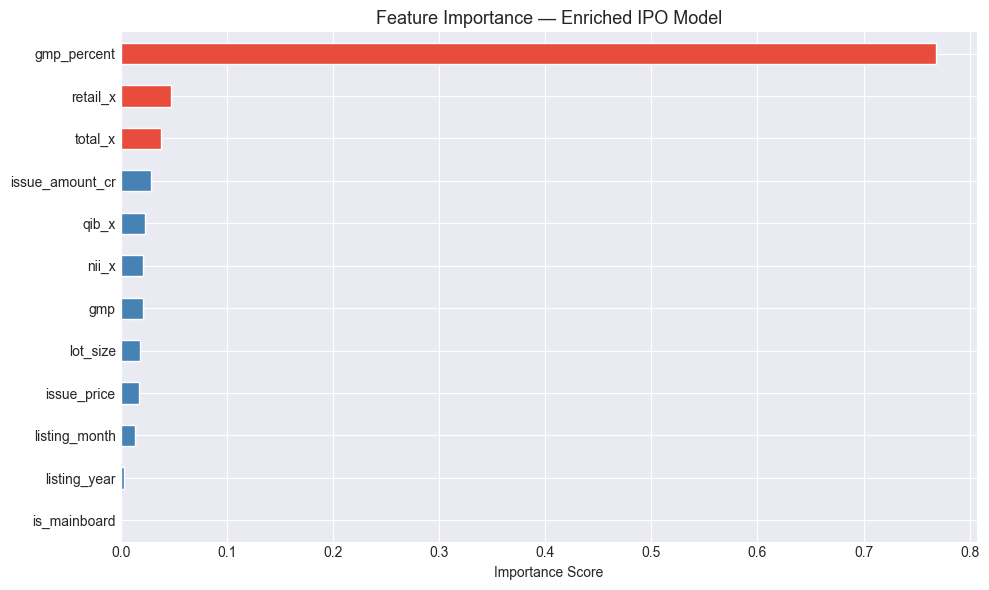

Top 5 features:
gmp_percent        0.768284
retail_x           0.047140
total_x            0.037838
issue_amount_cr    0.028627
qib_x              0.022975
dtype: float64


In [7]:
import joblib

# Train on full dataset for final model
rf.fit(X, y)

# Feature importance
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if i >= len(importances)-3 else 'steelblue' for i in range(len(importances))]
importances.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Importance — Enriched IPO Model', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/processed/plot_feature_importance_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 features:")
print(importances.tail(5).sort_values(ascending=False))

In [8]:
import os
os.makedirs('../ml/models', exist_ok=True)

# Save model
joblib.dump(rf, '../ml/models/ipo_predictor_rf.pkl')

# Save feature list
import json
with open('../ml/models/features.json', 'w') as f:
    json.dump(FEATURES, f)

# Save dataset
df_ml.to_csv('../data/processed/ipo_enriched_final.csv', index=False)

print("Saved:")
print("  ml/models/ipo_predictor_rf.pkl")
print("  ml/models/features.json")
print("  data/processed/ipo_enriched_final.csv")

Saved:
  ml/models/ipo_predictor_rf.pkl
  ml/models/features.json
  data/processed/ipo_enriched_final.csv
